# 02 Baseline Validation

This notebook checks that the baseline gas regulator behaves as expected.

The numerical solution is compared with the analytical equilibrium, the mass budget is checked, and the adopted baseline model is then run using the final initial conditions.

In [2]:
import sys
from pathlib import Path
sys.path.append("../model")

import numpy as np
import matplotlib.pyplot as plt

from parameters import BASE_PARAMS, INITIAL, TIME
from gas_regulator import run_model, quantities, equilibrium_values

output_path = Path("../output/figures")
output_path.mkdir(parents=True, exist_ok=True)

## 1 Test setup

The validation run begins away from equilibrium so that the model can be checked as it evolves toward the analytical solution.

The test uses

$$
M_{g,0}=2\times10^9\,M_\odot
$$

and

$$
Z_{g,0}=0.002.
$$

The physical parameters are unchanged from the adopted baseline model.

The 15 Gyr interval is used only to test the approach to equilibrium and is not treated as a physical evolutionary history.

In [3]:
params = BASE_PARAMS.copy()
test_initial = {"M_g": 2e9, "M_star": INITIAL["M_star"], "Z_g": 0.002}
t_test = np.linspace(0.0, 15.0, 1001)

print(f"Initial gas mass = {test_initial['M_g']:.2e} Msun")
print(f"Initial metallicity = {test_initial['Z_g']:.4f}")
print(f"Test duration = {t_test[-1]:.1f} Gyr")

Initial gas mass = 2.00e+09 Msun
Initial metallicity = 0.0020
Test duration = 15.0 Gyr


## 2 Numerical evolution

The three coupled equations for gas mass, stellar mass, and gas metal mass are integrated numerically.

If the implementation is consistent with the model equations, the gas mass, star formation rate, and metallicity should approach their analytical equilibrium values.

In [4]:
solution = run_model(params, test_initial, t_test)
data = quantities(solution, params)

M_g = solution.y[0]
M_star = solution.y[1]
Z_g = data["Z_g"]
Mdot_star = data["Mdot_star"]

print("Integration completed")

Integration completed


## 3 Analytical equilibrium check

For the baseline model,

$$
\dot M_{\star,{\rm eq}}=\frac{\dot M_{\rm in}}{1-R+\eta},
$$

$$
M_{g,{\rm eq}}=\tau_{\rm dep}\dot M_{\star,{\rm eq}},
$$

and

$$
Z_{\rm eq}=Z_{\rm in}+\frac{y(1-R)}{1-R+\eta}.
$$

The final numerical values are compared directly with these analytical results.

In [5]:
eq = equilibrium_values(params)

gas_error = abs(M_g[-1] - eq["M_g"]) / eq["M_g"]
sfr_error = abs(Mdot_star[-1] - eq["Mdot_star"]) / eq["Mdot_star"]
Z_error = abs(Z_g[-1] - eq["Z_g"]) / eq["Z_g"]

print("Gas mass")
print(f"Analytical = {eq['M_g']:.3e} Msun")
print(f"Numerical = {M_g[-1]:.3e} Msun")
print(f"Relative difference = {gas_error:.3e}")

print("\nSFR")
print(f"Analytical = {eq['Mdot_star']/1e9:.4f} Msun/yr")
print(f"Numerical = {Mdot_star[-1]/1e9:.4f} Msun/yr")
print(f"Relative difference = {sfr_error:.3e}")

print("\nMetallicity")
print(f"Analytical = {eq['Z_g']:.6f}")
print(f"Numerical = {Z_g[-1]:.6f}")
print(f"Relative difference = {Z_error:.3e}")

Gas mass
Analytical = 5.000e+09 Msun
Numerical = 4.997e+09 Msun
Relative difference = 5.356e-04

SFR
Analytical = 2.1277 Msun/yr
Numerical = 2.1265 Msun/yr
Relative difference = 5.356e-04

Metallicity
Analytical = 0.010067
Numerical = 0.010032
Relative difference = 3.548e-03


## 4 Equilibrium plots

Two plots are sufficient for the validation.

Gas mass tests the regulator mass equation, while metallicity tests the metal evolution equation. A separate SFR plot is unnecessary because the baseline model uses

$$
\dot M_{\star,{\rm SF}}=\frac{M_g}{\tau_{\rm dep}}.
$$

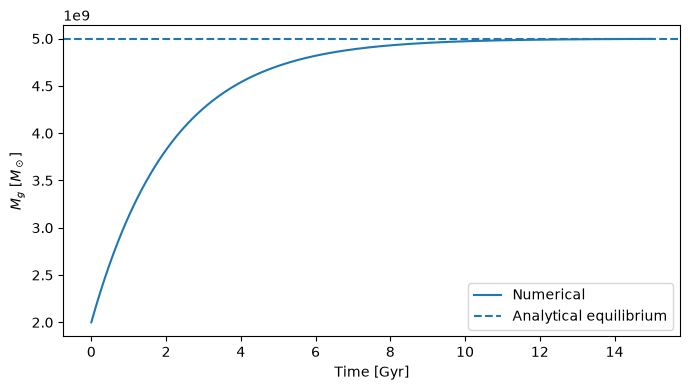

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(t_test, M_g, label="Numerical")
plt.axhline(eq["M_g"], linestyle="--", label="Analytical equilibrium")
plt.xlabel("Time [Gyr]")
plt.ylabel(r"$M_g$ [$M_\odot$]")
plt.legend()
plt.tight_layout()
plt.savefig(output_path / "baseline_gas_validation.png", dpi=300)
plt.show()

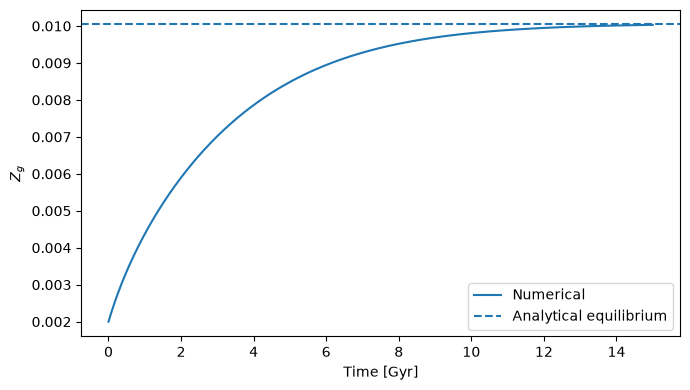

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(t_test, Z_g, label="Numerical")
plt.axhline(eq["Z_g"], linestyle="--", label="Analytical equilibrium")
plt.xlabel("Time [Gyr]")
plt.ylabel(r"$Z_g$")
plt.legend()
plt.tight_layout()
plt.savefig(output_path / "baseline_metallicity_validation.png", dpi=300)
plt.show()

## 5 Mass conservation

The total baryonic mass must satisfy

$$
M_g+M_\star+M_{\rm out,cum}
=
M_{g,0}+M_{\star,0}+M_{\rm in,cum}.
$$

Stellar mass return is internal to the gas-star system, so it does not add or remove mass from this total budget.

The cumulative inflow and outflow are therefore compared with the final gas and stellar masses.

In [8]:
M_in = params["Mdot_in"] * (t_test[-1] - t_test[0])
M_out = np.trapezoid(data["Mdot_out"], t_test)

mass_expected = test_initial["M_g"] + test_initial["M_star"] + M_in - M_out
mass_numerical = M_g[-1] + M_star[-1]
mass_error = abs(mass_numerical - mass_expected) / mass_expected

print(f"Expected final mass = {mass_expected:.6e} Msun")
print(f"Numerical final mass = {mass_numerical:.6e} Msun")
print(f"Relative mass difference = {mass_error:.3e}")

Expected final mass = 7.251136e+10 Msun
Numerical final mass = 7.251136e+10 Msun
Relative mass difference = 7.734e-08


## 6 Adopted baseline reference run

No parameter calibration is performed in this notebook.

The numerical and analytical checks above validate the implementation. The model is now run using the adopted initial conditions from `parameters.py`.

The initial gas mass is already at gas-mass equilibrium, so $M_g$ and the SFR should remain constant. The initial metallicity is below $Z_{\rm eq}$, so $Z_g$ should increase toward its equilibrium value.

In [9]:
reference_solution = run_model(BASE_PARAMS, INITIAL, TIME)
reference = quantities(reference_solution, BASE_PARAMS)
reference_eq = equilibrium_values(BASE_PARAMS)

print("Gas mass")
print(f"Initial = {reference_solution.y[0, 0]:.3e} Msun")
print(f"Final = {reference_solution.y[0, -1]:.3e} Msun")
print(f"Equilibrium = {reference_eq['M_g']:.3e} Msun")

print("\nSFR")
print(f"Initial = {reference['Mdot_star'][0]/1e9:.4f} Msun/yr")
print(f"Final = {reference['Mdot_star'][-1]/1e9:.4f} Msun/yr")
print(f"Equilibrium = {reference_eq['Mdot_star']/1e9:.4f} Msun/yr")

print("\nMetallicity")
print(f"Initial = {reference['Z_g'][0]:.6f}")
print(f"Final = {reference['Z_g'][-1]:.6f}")
print(f"Equilibrium = {reference_eq['Z_g']:.6f}")

Gas mass
Initial = 5.000e+09 Msun
Final = 5.000e+09 Msun
Equilibrium = 5.000e+09 Msun

SFR
Initial = 2.1277 Msun/yr
Final = 2.1277 Msun/yr
Equilibrium = 2.1277 Msun/yr

Metallicity
Initial = 0.006700
Final = 0.010036
Equilibrium = 0.010067
